# Session 1, Demo — First look at the warehouse data

**What this demo covers.** The *first-contact routine* — what an analyst does in the first ten minutes with any unknown table, and what you'll run on every new dataset for the rest of your career:

`load → head → shape → dtypes → describe → value_counts → one simple chart`

…plus the course's first **AI moment**: how to ask an assistant for help so the answer is actually useful.

**Data.** One week of picking operations from the ALPHA warehouse — closely modelled on a real e-commerce site. Column meanings: see the [data dictionary](../../data/README.md).

**How to run.** Locally: run top to bottom, the data is already in the repo. On Google Colab: uncomment the marked lines in the setup cell. No working environment yet? [00-setup.md](../00-precourse/00-setup.md) walks through both, step by step.

## 0. Setup

The cell below prepares three things and prints nothing:

- `import pandas as pd` loads the table library, under the short name `pd` everybody uses (it is possible to write `import pandas`, but alias for this library is common).
- `from pathlib import Path` loads a small helper for file addresses (pathlib included in the default set of Python libraries)
- `DATA = Path("../../data/alpha")` is the data folder, written as an address **relative to this notebook**. Each `..` means "one folder up": up from `01-intro` to `lectures`, up again to the course root, then down into `data/alpha`.

Later we write `DATA / "picking_events.parquet"`. A slash between a `Path` and a file name builds the full address, and that one line then works on Windows, macOS and Colab alike.

If some cell greets you with `FileNotFoundError`, the address is wrong, not your Python: run `print(Path.cwd())` to see which folder the notebook is actually sitting in. The rest of the first-week errors are collected in [00-setup.md](../00-precourse/00-setup.md).

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib

## 1. Load and look

Rule one: **look at the thing before computing anything.**

Before the big table, one small one, where every number can be checked by eye. In the primer we built a list of dictionaries and said it was almost a table: one dict per order, the same keys in each. pandas turns that "almost" into a real table.

In [2]:
# the primer's orders: one dictionary per order
toy_orders = [
    {"city": "Moscow", "amount": 1500, "paid": True},
    {"city": "Kazan", "amount": 900, "paid": False},
    {"city": "Moscow", "amount": 2300, "paid": True},
]

toy_sales = pd.DataFrame(toy_orders) # pd.DataFrame creates a table object
toy_sales

,city,amount,paid
0,Moscow,1500,True
1,Kazan,900,False
2,Moscow,2300,True


That object is a **DataFrame**: the pandas word for one table. Three rows, three columns, and the `0, 1, 2` on the left are row labels (index) that pandas added for us.

Two commands we will use on every table tonight:

- `table["column_name"]` gives back that one column, asked for by name.
- `table.shape` gives the size as `(rows, columns)`, in that order.

In [3]:
print(toy_sales.shape)  # (rows, columns): three orders, three columns

toy_sales["amount"]  # one column, asked for by name

(3, 3)


0    1500
1     900
2    2300
Name: amount, dtype: int64

One column on its own is called a **Series**: the values, plus the same row labels (index).

The two commands work the same on a table of any size, so now the real one. Our data sits in `.parquet` files. That is a table stored as a file, like CSV, but it keeps the column types and takes several times less space, which is why companies store tables this way. `pd.read_parquet` opens it, and `.head()` shows the first rows exactly as they are stored.

In [4]:
events = pd.read_parquet(DATA / "picking_events.parquet")

# pandas can read just about any format you'll run into
# events = pd.read_csv(DATA / "picking_events.csv", delimiter=',') # comma- or tab-separated text
# events = pd.read_excel(DATA / "picking_events.xlsx") # needs the openpyxl library
# events = pd.read_json(DATA / "picking_events.json")

events.head()

,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
0,2026-03-02 11:51:59.142,StartTask,4500859,800000001,NaN,NaN,NaN,NaN,NaN
1,2026-03-02 11:53:33.779,ScanCell,4500859,800000001,54400900.0,NaN,NaN,135.0,NaN
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
3,2026-03-02 11:53:56.955,PickCorrectItem,4500859,800000001,54400900.0,10000001.0,1.679524e+09,135.0,NaN
4,2026-03-02 11:54:40.688,ScanCell,4500859,800000001,43583220.0,NaN,NaN,12.0,NaN


Every row is **one scan of a picker's handheld terminal**. Nine columns of ids and timestamps, and none of it means anything until you know what the picker was doing when the row appeared. So: the process first, then the same thing in the data.

One crucial thing: you need to understand that the data you see above only tries to show you how the process works and includes some stages of the real physical process behind it. For example, you don't have a log entry for the physical picking of an empty container, but knowing that this event happened may help you explain why there is a delay between the StartTask event and the ScanCell event.

### Where this table comes from

A fulfillment warehouse is a chain of stages. Our file covers exactly one of them:

```text
   INBOUND            STORAGE              PICKING  ← this file        OUTBOUND
 ┌───────────┐    ┌──────────────┐    ┌──────────────────────┐    ┌──────────────┐
 │ truck     │    │ item put     │    │ order arrives        │    │ items of one │
 │ arrives   │───▶│ into a cell  │───▶│ system builds a task │───▶│ order meet,  │
 │ items     │    │ on a rack    │    │ picker walks & scans │    │ get packed   │
 │ scanned   │    │              │    │ container filled     │    │ and shipped  │
 └───────────┘    └──────────────┘    └──────────────────────┘    └──────────────┘
                                       picking_events.parquet
```

### One task, step by step

A **task** is one trip: the terminal hands a picker a list of "go there, take that", and the picker walks it. Every scan on the way writes one row.

```text
 StartTask                    the picker accepts the task and physically takes an empty container
     │
     ├── ScanCell             walk to the cell the terminal shows, scan the shelf barcode
     │      ├── PickCorrectItem   scan the item: right one, goes into the container
     │      ├── PickWrongItem     scan the item: wrong one, keep searching this cell
     │      ├── SkipItem          the item is not in the cell at all
     │      └── MarkDefectItem    the item is there but damaged
     │
     ├── ScanCell             next cell, same story
     │      └── ...           around 30 cells in a typical task (5 to 50)
     │
     ├── DropBoxing           container full: leave it at a drop point, take an empty one
     │                        (a task fills 1 to 4 containers, each with its own id)
     │
     └── FinishTask           every line done, the task closes
```

Why a wrong scan happens at all: one cell can hold several different products, side by side. The picker grabs what looks right and scans it, the terminal compares the barcode with the task and says no, and the search inside that cell continues.

### What each column is for

| column | the question it answers | in the story above |
|---|---|---|
| `event_time` | when? | the moment of the scan, to the millisecond |
| `event_type` | what happened? | one of the eight steps in the diagram |
| `user_id` | who? | the picker, under an anonymous id |
| `task_id` | which trip? | one walk through the diagram, start to finish |
| `cell_id` | where? | the storage cell being worked on |
| `boxing_id` | into which container? | changes every time a full one is dropped |
| `item_id` | what? | the item that was scanned |
| `items_in_cell_quantity` | how many were there? | units sitting in that cell at that moment |
| `reason` | why? | a note the terminal adds to *some* events, mostly empty |

Not every step fills every column: a picker walking to a cell has no item in hand yet. Which columns each event type leaves empty, and what that says about the process, is next week's detective work. You can already guess most of it from the diagram.

A column only makes sense when you know **which real-world action fills it**, which is why tonight started with the warehouse process, not with pandas.

In [5]:
first_task_id = events["task_id"][0]

# picking rows out of a table is next week's topic:
# read the line below as "keep only the rows of that one task"
one_task = events[events["task_id"] == first_task_id]

print(f"task {first_task_id}: {len(one_task)} rows")
one_task

task 800000001: 27 rows


,event_time,event_type,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity,reason
0,2026-03-02 11:51:59.142,StartTask,4500859,800000001,NaN,NaN,NaN,NaN,NaN
1,2026-03-02 11:53:33.779,ScanCell,4500859,800000001,54400900.0,NaN,NaN,135.0,NaN
2,2026-03-02 11:53:47.415,PickWrongItem,4500859,800000001,54400900.0,10000001.0,3.014677e+09,135.0,WRONG_ITEM
3,2026-03-02 11:53:56.955,PickCorrectItem,4500859,800000001,54400900.0,10000001.0,1.679524e+09,135.0,NaN
4,2026-03-02 11:54:40.688,ScanCell,4500859,800000001,43583220.0,NaN,NaN,12.0,NaN
5,2026-03-02 11:54:44.531,PickCorrectItem,4500859,800000001,43583220.0,10000001.0,1.430083e+09,12.0,NaN
6,2026-03-02 11:55:18.714,ScanCell,4500859,800000001,100180332.0,NaN,NaN,11.0,NaN
7,2026-03-02 11:55:25.176,PickCorrectItem,4500859,800000001,100180332.0,10000001.0,1.965323e+09,11.0,NaN
8,2026-03-02 11:55:51.419,ScanCell,4500859,800000001,119816855.0,NaN,NaN,33.0,NaN
9,2026-03-02 11:55:58.234,PickCorrectItem,4500859,800000001,119816855.0,10000001.0,2.422287e+09,33.0,NaN


Read it from the top and the diagram is right there in the data: the task opens, the picker scans a cell, grabs the wrong item once and then the right one, moves on. Two picks in a row from the same `cell_id` mean two units taken during one visit, and `items_in_cell_quantity` ticks down by one between them. At the end the container is dropped and the task closes.

One trip, one `task_id`. This one is a short trip at 27 rows; seventy-odd is more typical. The file holds about four thousand of these trips, which is where all those rows come from. How many rows exactly?

In [6]:
events.shape

(311543, 9)

~312 thousand events, 9 columns, and that is only one week of data. Too big for eyeballing, trivial for code.

## 2. What types did we get?

As we know python has types such as `int`, `float`, `str`, `bool`, so we might expect the same types to be available in pandas.

But it's not quite right: pandas is written in `C` (another programming language) under the hood, so it has its own data types (similar to python's ones). 

Let's check

In [7]:
events.dtypes

event_time                datetime64[us]
event_type                           str
user_id                            int64
task_id                            int64
cell_id                          float64
boxing_id                        float64
item_id                          float64
items_in_cell_quantity           float64
reason                               str
dtype: object

Let's go step by step:

1. `event_time` arrived as a proper datetime — good, time math will just work. The cell below takes the column, then its first value.

In [8]:
ts = events['event_time'][0] # a Timestamp knows its own date and time parts
ts.date(), ts.time(), ts.day

(datetime.date(2026, 3, 2), datetime.time(11, 51, 59, 142000), 2)

2. `user_id` and `task_id` came in as `int64`. What does the "64" mean?
    - Read it as "a whole number". That is all you need to know most of the time.
    - The number says how much room pandas keeps for each value. `int64` uses 64 bits, so it holds anything from about minus nine quintillion to plus nine quintillion. `int8` uses 8 bits and holds only -128 to 127.
    - Bigger type, bigger numbers, more memory. In this course the choice never matters, so leave everything as `int64`.

3. But look at `cell_id`, `boxing_id`, `item_id`: **floats**. Ids with a decimal point?! That's pandas telling us these columns contain *empty values* — a float `NaN` is how it marks a hole. Which events leave which columns empty, and why, is next week's detective work. For now, just notice that the data is telling us something.

One more reading skill before the next cell. On big numbers pandas switches to scientific notation: `3.115430e+05` means 3.115430 with the dot moved five places to the right, so 311,543. Read `e+05` as "times ten to the fifth".

In [9]:
events.describe()

,event_time,user_id,task_id,cell_id,boxing_id,item_id,items_in_cell_quantity
count,311543,3.115430e+05,3.115430e+05,3.032290e+05,1.863230e+05,1.721890e+05,295954.000000
mean,2026-03-05 20:51:29.526535,6.342057e+06,8.011744e+08,9.905543e+07,1.007790e+07,1.757022e+09,24.979287
min,2026-03-02 11:51:59.142000,2.214416e+06,8.000000e+08,3.001785e+07,1.000000e+07,1.000610e+08,0.000000
25%,2026-03-04 02:12:34.953500,3.792068e+06,8.006636e+08,6.406116e+07,1.003705e+07,9.229166e+08,7.000000
50%,2026-03-05 22:02:24.491000,6.316178e+06,8.011795e+08,9.774607e+07,1.008482e+07,1.762329e+09,15.000000
75%,2026-03-07 16:19:31.037500,8.735343e+06,8.018562e+08,1.328572e+08,1.012045e+07,2.581411e+09,31.000000
max,2026-03-09 00:46:59.215000,9.989469e+06,8.023711e+08,1.699701e+08,1.016216e+07,3.399984e+09,332.000000
std,NaN,2.533465e+06,7.211558e+05,4.007499e+07,4.633834e+04,9.559653e+08,30.235285


On a table of ids `describe()` is mostly noise — the *mean of an id* means nothing. 

But one row is genuinely useful: **`count` differs by column**, the empty values again, now counted. 

Knowing which summary makes sense for which column is exactly the analyst's job; a tool will happily average your phone numbers.


One more function worth knowing: `info()`. It puts the column names, the count of filled values and the data types into a single summary. Nothing new in it: that is `dtypes` plus the `count` row of `describe()` in one view. Treat it as a shortcut, not a seventh step of the first-contact routine.

In [10]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 311543 entries, 0 to 311542
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   event_time              311543 non-null  datetime64[us]
 1   event_type              311543 non-null  str           
 2   user_id                 311543 non-null  int64         
 3   task_id                 311543 non-null  int64         
 4   cell_id                 303229 non-null  float64       
 5   boxing_id               186323 non-null  float64       
 6   item_id                 172189 non-null  float64       
 7   items_in_cell_quantity  295954 non-null  float64       
 8   reason                  33317 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 25.3 MB


## 3. What happens in this warehouse?

Let's see the distribution of events frequency

In [11]:
events["event_type"].value_counts()

event_type
PickCorrectItem    145904
ScanCell           116733
PickWrongItem       33317
DropBoxing           7102
StartTask            4237
FinishTask           4077
SkipItem              126
MarkDefectItem         47
Name: count, dtype: int64

Now the **sanity check against the process story** we told before the break:

- Every task starts exactly once → `StartTask` should be one of the rarest types. ✔
- More *picks* than *cell scans* — can that be right? (Think: several items picked from one cell visit.) ✔
- `PickWrongItem` is **not rare**: roughly one wrong scan for every few correct ones. A wrong scan happens when a cell holds several products and the picker grabs the wrong one; the terminal rejects it and the search continues. Is that *a lot*? **That's not a pandas question — that's a question for the warehouse manager.** Write it down; in two weeks it becomes a hypothesis.
- Subtle one: slightly fewer `FinishTask` than `StartTask`. Noted. Next week.

## 4. Events over time — the first chart

One aggregate anyone understands: **how many events per day**. Group by the calendar date (`.dt.date` pulls it out of the timestamp), count rows, draw a line.

In [12]:
# a simple groupby — we talk about what it does next week
events_per_day = events.groupby(events["event_time"].dt.date).size()
events_per_day

event_time
2026-03-02    25857
2026-03-03    44066
2026-03-04    43238
2026-03-05    46289
2026-03-06    46210
2026-03-07    52513
2026-03-08    52763
2026-03-09      607
dtype: int64

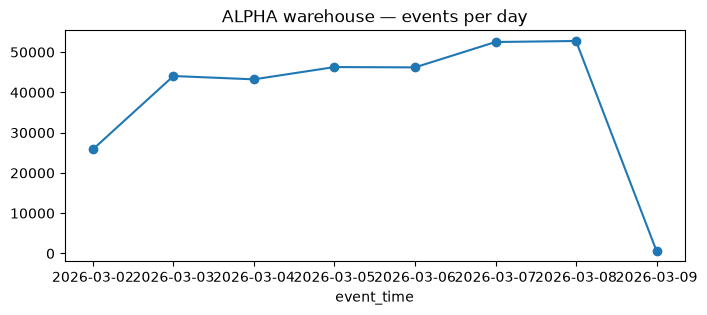

In [13]:
events_per_day.plot(
    marker="o",
    figsize=(8, 3),
    title="ALPHA warehouse — events per day",
)
plt.show()

An honest chart — and an ugly, shallow one. Two things to notice:

1. **The edges are weird.** The first day looks low, and there's a tiny March 9 tail. Neither is a mystery: the extract starts midday Monday, and tasks that started Sunday evening were kept whole. *Always find the edges of your data before you compare anything.*
2. **One point per day hides the rhythm.** I want *hourly* volume with readable day ticks… and I don't remember matplotlib's date-formatting incantations. Nobody remembers those. That used to be a real problem. It isn't any more.

*Time for the AI moment.*

## 5. The AI moment: ask so the answer is useful

**The lazy way** (watch it fail):

> my chart looks bad, fix it

The assistant knows nothing about your data, your library, or what "bad" means. You'll get a generic lecture on chart design and code for a dataframe you don't have.

**The useful way** — role, context, what I have, what I want, constraints:

> You are a Python data analyst. I have a pandas DataFrame `events` with a datetime64 column `event_time`: one week of warehouse scan events (2026-03-02 to 03-09, ~300k rows). Using matplotlib, plot the **number of events per hour** as a line chart: x-axis ticks per day formatted like "Mon 02", labeled axes, figure about 12×4. Return only the code and assume `events` already exists.

Below is the code the assistant returned. **Read it line by line before running.** That's the rule.

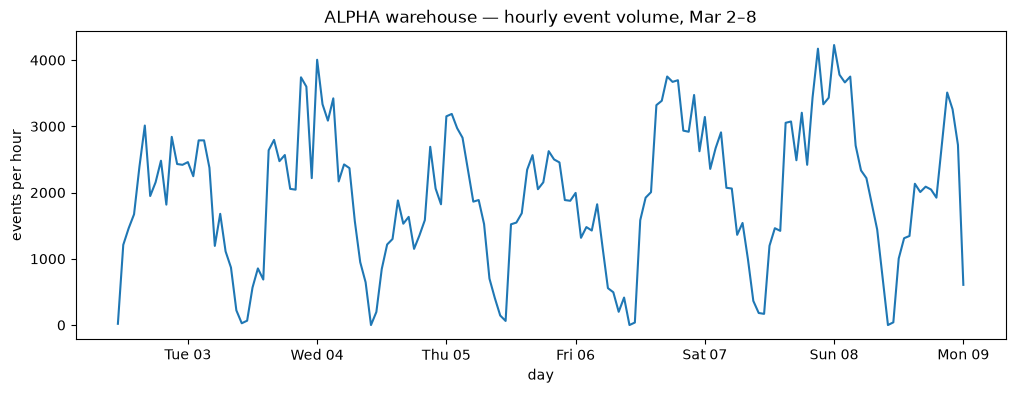

In [14]:
# code returned by the assistant: read every line, then run it
import matplotlib.dates as mdates

events_per_hour = (
    events
    .set_index("event_time")
    .resample("1h")
    .size()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(events_per_hour.index, events_per_hour.values)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
ax.set_xlabel("day")
ax.set_ylabel("events per hour")
ax.set_title("ALPHA warehouse — hourly event volume, Mar 2–8")
plt.show()

**Now verify — on the data, not on vibes:**

- The daily rhythm exists and repeats — the resample did what we meant. ✔
- Nights are *not* empty: the site runs around the clock. Did you expect that? The metadata (`warehouse_info.pickle`) and the process story agree. ✔
- Every day shows a **dip around 9–11**. The chart cannot tell you why — a person who runs the process can. A real analyst's next move here is *a question, not more code*.

And that's the loop this course keeps returning to: **think → ask well → verify.**

## 6. Try it yourself

Three questions, answerable with only what you saw tonight:

1. How many **different pickers** worked this week? *(one method on one column — if you don't know it, ask your assistant well)*
2. Which **day** was the busiest, and which **hour** of the whole week? *(`events_per_day` and `events_per_hour` are already in memory)*
3. From the process story: which event types would you *expect* to have an empty `item_id`? Check your guess against the data.

In [15]:
# your turn


## Recap

- Data is the **result of a business process** — to read a table, know the process.
- First-contact routine, always: `head → shape → dtypes → describe → value_counts → one chart`.
- Floats where ids should be = empty values hiding; `count` in `describe()` confirms.
- A chart is a **question generator**: weird edges, dips and spikes are questions to humans, not answers.
- The AI loop: **think → ask well (role, context, what you have, what you want) → verify on the data.**

Next Wednesday: filtering, grouping and joining — the warehouse starts answering real questions.